# **Import Required Libraries**

we import all the libraries required for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)




---



# **Task 1: Data Loading & Exploration**


## **Load the CSV file using Pandas**

Load the IBM HR Analytics dataset into a Pandas DataFrame.


In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

## **Display the first 10 rows**

Understanding the structure and contents of the dataset.

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## **Dataset Shape**

Check total rows and columns.

In [6]:
# (row, column)

df.shape

(1470, 35)

## **Dataset Information**

Understand column names and data types.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## **Target Variable Analysis**

Identify the target column

Identify the target column (Attrition — Yes/No)

In [8]:
attrition_count = df["Attrition"].value_counts()

print("Attrition Counts: \n")
print(attrition_count)

Attrition Counts: 

Attrition
No     1233
Yes     237
Name: count, dtype: int64


## **Calculate Attrition Rate**

In [9]:
attrition_rate = (attrition_count['Yes'] / len(df)) * 100

print(f"\nAttrition Rate: {attrition_rate:.2f}%")


Attrition Rate: 16.12%


## **Numeric vs Categorical Columns**

Identify feature types.

In [10]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes("object").columns

print("Numeric Columns: \n")
print(numeric_cols)

print("\nCategorical Columns: \n")
print(categorical_cols)

Numeric Columns: 

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns: 

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


## **Observation**

The dataset is imbalanced because employees who stayed are significantly higher than employees who left. Attrition rate is approximately 16%, indicating a class imbalance problem.



---



# **Task 2: Data Cleaning & Preprocessing**


## **Check Missing Values**


In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## **Remove Irrelevant Columns**

Drop columns that do not contribute to prediction.

In [12]:
df.drop(
  columns=[
        'EmployeeNumber',
        'Over18',
        'StandardHours',
        'EmployeeCount'
    ],
    inplace = True
)

## **Convert Target Variable**

Convert Attrition from Yes/No into 1/0.

In [13]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

## **Separate Features and Target**

In [14]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

## **One-Hot Encoding**

Convert categorical variables into numerical format.

In [15]:
x = pd.get_dummies(x, drop_first=True)

print(x)

      Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0      41       1102                 1          2                        2   
1      49        279                 8          1                        3   
2      37       1373                 2          2                        4   
3      33       1392                 3          4                        4   
4      27        591                 2          1                        1   
...   ...        ...               ...        ...                      ...   
1465   36        884                23          2                        3   
1466   39        613                 6          1                        4   
1467   27        155                 4          3                        2   
1468   49       1023                 2          3                        4   
1469   34        628                 8          3                        2   

      HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  Mo

## **Feature Scaling**

Standardize numerical features.

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

print(X_scaled)

[[ 0.4463504   0.74252653 -1.01090934 ... -0.91892141  1.45864991
   1.59174553]
 [ 1.32236521 -1.2977746  -0.14714972 ...  1.08823234 -0.68556546
  -0.62824112]
 [ 0.008343    1.41436324 -0.88751511 ... -0.91892141  1.45864991
   1.59174553]
 ...
 [-1.08667552 -1.60518328 -0.64072665 ...  1.08823234 -0.68556546
   1.59174553]
 [ 1.32236521  0.54667746 -0.88751511 ...  1.08823234 -0.68556546
  -0.62824112]
 [-0.32016256 -0.43256792 -0.14714972 ...  1.08823234 -0.68556546
  -0.62824112]]




---



# **Task 3: Exploratory Data Analysis (EDA)**

## **Attrition by Department**

Analyze which department loses the most employees.

In [17]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


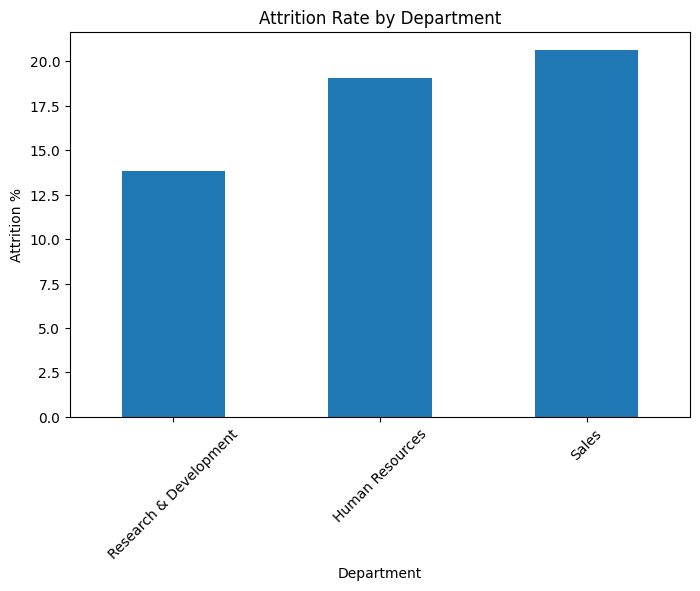

In [18]:
department_attrition[1].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Department')
plt.ylabel('Attrition %')
plt.xticks(rotation=45)

plt.show()

## **Attrition by Job Role**

Identify job roles with highest attrition.

In [19]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
)*100

jobrole_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


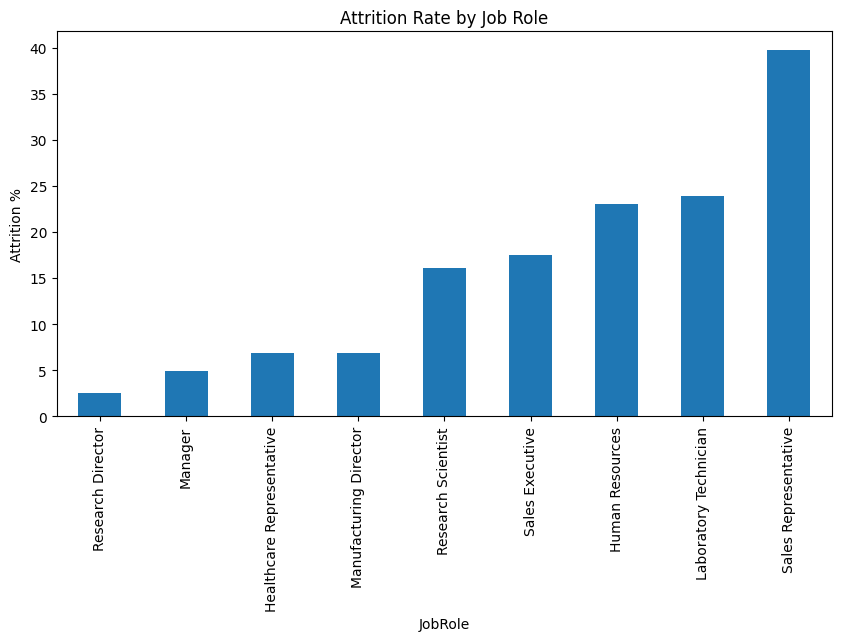

In [20]:
jobrole_attrition[1].sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Attrition Rate by Job Role')
plt.ylabel('Attrition %')

plt.show()

## **Attrition vs Monthly Income**

Analyze income differences between employees who stayed and left.

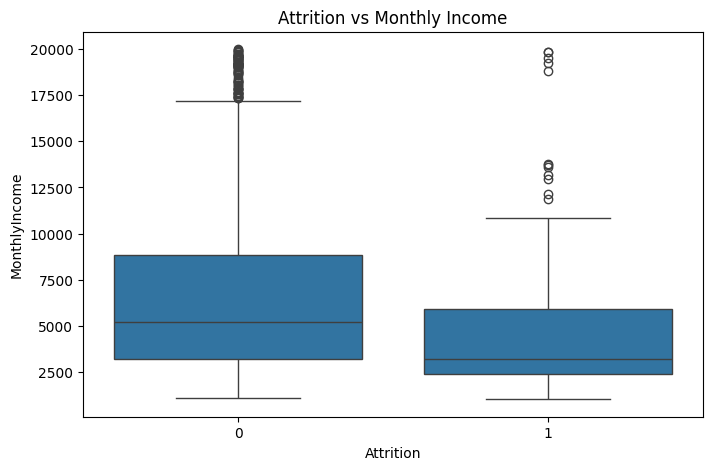

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title('Attrition vs Monthly Income')
plt.show()

## **Attrition vs Work-Life Balance**

Check whether work-life balance impacts employee retention.

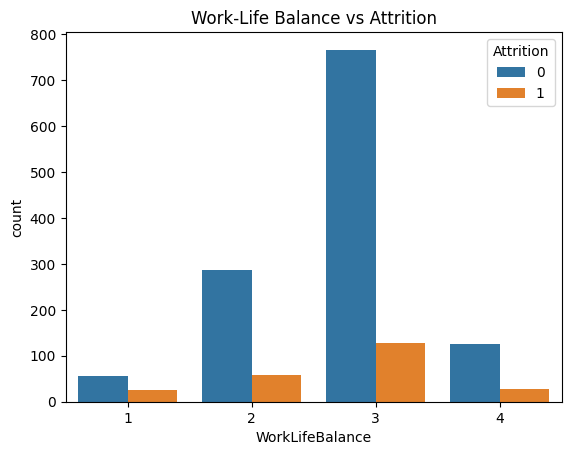

In [22]:
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.title('Work-Life Balance vs Attrition')
plt.show()

## **Attrition vs Years at Company**

Analyze employee tenure before leaving.

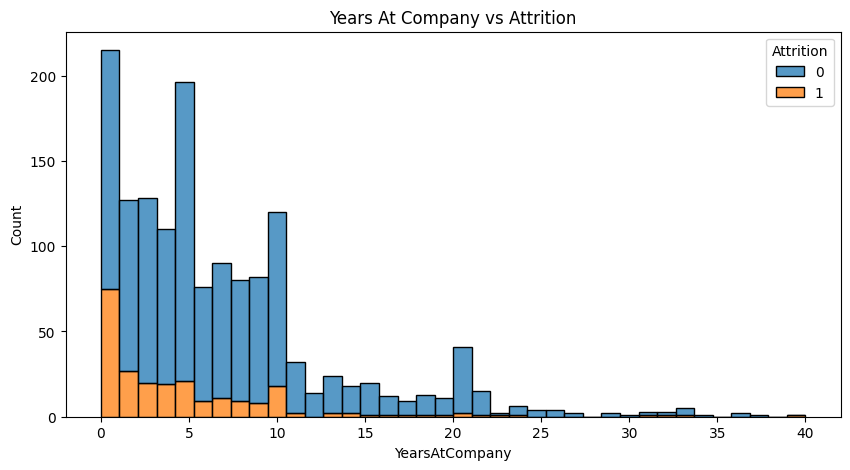

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)

plt.title('Years At Company vs Attrition')
plt.show()

## **Business Insights**

1. Sales department shows the highest attrition rate among all departments.

2. Sales Representatives and Laboratory Technicians experience the highest employee exits.

3. Employees with lower monthly income tend to leave more frequently.

4. Employees with poor work-life balance ratings show higher attrition.

5. Most employees leave within the first 5 years of joining the company.



---



# **Task 4: Model Building & Comparison**

## **Train-Test Split**

The dataset was divided into training and testing sets to evaluate model performance on unseen data.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1176, 44)
X_test Shape: (294, 44)
y_train Shape: (1176,)
y_test Shape: (294,)


## **Logistic Regression**

In [25]:
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [26]:
print("First 10 Predictions:")
print(lr_pred[:10])

print("\nFirst 10 Probability Scores:")
print(lr_prob[:10])

First 10 Predictions:
[0 0 0 0 1 1 0 0 0 0]

First 10 Probability Scores:
[0.28348611 0.01938263 0.31491027 0.04695525 0.68391471 0.65409691
 0.07951527 0.18445858 0.01834157 0.2214166 ]


## **Gradient Boosting**

In [27]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]

In [28]:
print("First 10 Predictions:")
print(gb_pred[:10])

print("\nFirst 10 Probability Scores:")
print(gb_prob[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Probability Scores:
[0.48929746 0.01851334 0.1307135  0.00909829 0.28819942 0.10216295
 0.0732031  0.05643441 0.01215591 0.46121736]


## **Random Forest Classifier**

In [29]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [30]:
print("First 10 Predictions:")
print(rf_pred[:10])

print("\nFirst 10 Probability Scores:")
print(rf_prob[:10])

First 10 Predictions:
[1 0 0 0 0 0 0 0 0 0]

First 10 Probability Scores:
[0.615 0.03  0.085 0.005 0.23  0.105 0.03  0.07  0.01  0.4  ]


## **Model Comparison Table**

Compare all models using evaluation metrics.

In [31]:
results = pd.DataFrame({

'Model':['Logistic Regression',
         'Random Forest',
         'Gradient Boosting'],

'Precision':[
precision_score(y_test,lr_pred),
precision_score(y_test,rf_pred),
precision_score(y_test,gb_pred)
],

'Recall':[
recall_score(y_test,lr_pred),
recall_score(y_test,rf_pred),
recall_score(y_test,gb_pred)
],

'F1 Score':[
f1_score(y_test,lr_pred),
f1_score(y_test,rf_pred),
f1_score(y_test,gb_pred)
],

'ROC AUC':[
roc_auc_score(y_test,lr_prob),
roc_auc_score(y_test,rf_prob),
roc_auc_score(y_test,gb_prob)
]

})

results

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.571429,0.085106,0.148148,0.771643
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125




---



# **Task 5: Model Evaluation**

## **Classification Reports**

Classification metrics were analyzed to evaluate how effectively each model predicts employee attrition.

In [32]:
print("Logistic Regression")
print(classification_report(y_test,lr_pred))

print("Random Forest")
print(classification_report(y_test,rf_pred))

print("Gradient Boosting")
print(classification_report(y_test,gb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.8

## **Confusion Matrix**

In [33]:
print("Logistic Regression")
print(classification_report(y_test,lr_pred))

print("Random Forest")
print(classification_report(y_test,rf_pred))

print("Gradient Boosting")
print(classification_report(y_test,gb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.8

## **Best Model**

Gradient Boosting achieved the highest ROC-AUC and F1 Score, making it the best-performing model for attrition prediction.

## **Feature Importance**

Identify top drivers of attrition.

In [34]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047109
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043466
4,EnvironmentSatisfaction,0.038851
6,JobInvolvement,0.038142




---



# **Task 6: Visualizations**

## **Chart 1: Attrition by Department**

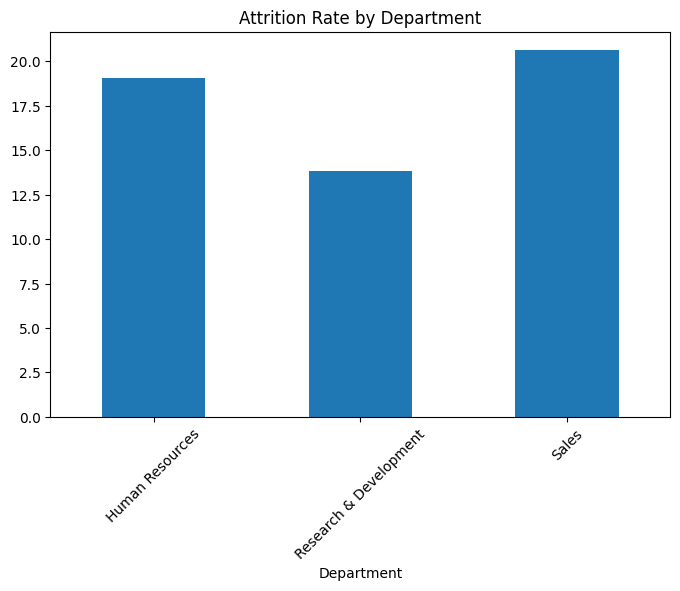

In [35]:
department_attrition[1].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Department')
plt.xticks(rotation=45)

plt.show()

## **Chart 2: Monthly Income vs Attrition**

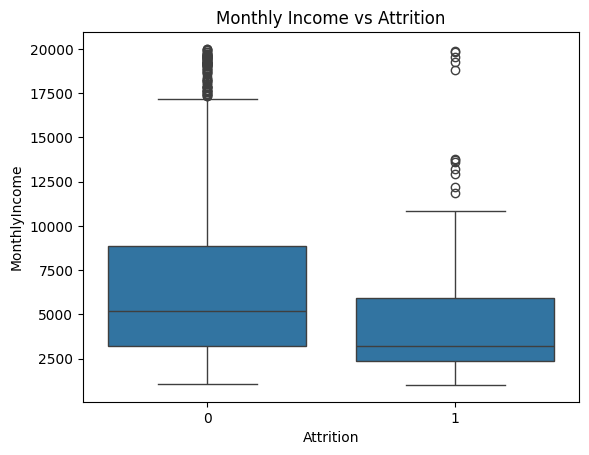

In [39]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title('Monthly Income vs Attrition')

plt.show()

## **Chart 3: Confusion Matrix**

The confusion matrix evaluates how accurately the model classifies employees into attrition and non-attrition categories.

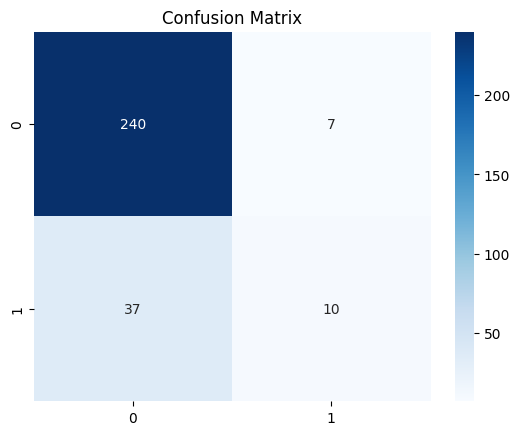

In [40]:
sns.heatmap(
    confusion_matrix(y_test, gb_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.show()

## **Chart 4: Top 10 Feature Importances**

Feature importance analysis identifies the variables that contribute most to employee attrition prediction.Classification Report

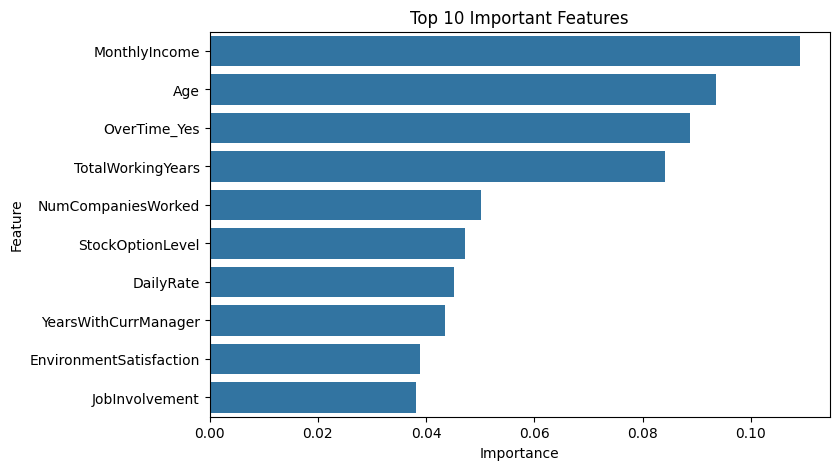

In [38]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title('Top 10 Important Features')
plt.show()



---



# **Task 7: HR Insights & Recommendations**

## **Which 3 factors most strongly predict that an employee will leave?**

* Overtime – Employees who frequently work overtime are more likely to leave the organization due to increased workload and work-related stress.

* Monthly Income – Employees with lower salaries tend to have a higher attrition rate, indicating that compensation plays an important role in retention.

* Years at Company – Employees with shorter tenure are more likely to leave, especially during the early years of employment.

## **Which department or job role should HR prioritize for retention efforts?**

* Sales Department should be the primary focus for retention efforts, as it generally experiences the highest attrition rate among departments.

* Sales Representatives show one of the highest employee exit rates and require targeted retention strategies.

* Laboratory Technicians also demonstrate relatively high attrition and should be monitored closely.

* HR should prioritize employees in these roles for engagement programs, career development opportunities, and retention discussions.

* Early intervention in these high-risk groups can help reduce employee turnover and improve workforce stability.

## **Does salary alone explain attrition or are there other stronger factors?**

Salary alone does not explain employee attrition. Although employees with lower income are more likely to leave, factors such as overtime, years at the company, work-life balance, and job satisfaction also play a major role. This suggests that attrition is influenced by a combination of compensation, workload, and workplace experience rather than salary alone.

## **Write 2 concrete HR recommendations a company could implement based on your findings.**

1. Reduce employee overtime and improve work-life balance by monitoring workloads, encouraging flexible work arrangements, and ensuring employees are not consistently overworked. This can help lower stress and reduce attrition risk.

2. Implement targeted retention programs for new and high-risk employees, especially in departments or job roles with high attrition. Regular career development discussions, mentoring, and growth opportunities can improve employee engagement and retention.

## **What limitation does this model have that an HR team should be aware of before using it?**

The model is based on historical employee data and may not capture personal or external factors influencing attrition, such as family circumstances, health issues, workplace culture, or better job opportunities elsewhere. Therefore, its predictions should be used as a decision-support tool rather than the sole basis for HR decisions.